# Стакинг ансамбль с использованием логистической регрессии

Используется устройство: cuda

=== Подготовка данных для Stacking ===


Предсказания ViTEmotion: 100%|██████████| 96/96 [00:16<00:00,  5.70it/s]


Размер признакового пространства: 21


РЕЗУЛЬТАТЫ STACKING


Val Accuracy:   0.9908
Test Accuracy:  0.8915
Test Macro F1:  0.8250

Per-class F1-score (Stacking):
              precision    recall  f1-score   support

    Surprise      0.898     0.906     0.902       329
        Fear      0.788     0.554     0.651        74
     Disgust      0.766     0.613     0.681       160
   Happiness      0.935     0.968     0.951      1185
     Sadness      0.876     0.858     0.867       478
       Anger      0.903     0.802     0.850       162
     Neutral      0.852     0.899     0.875       680

    accuracy                          0.891      3068
   macro avg      0.860     0.800     0.825      3068
weighted avg      0.889     0.891     0.889      3068



Матрица ошибок (Confusion Matrix) для Test


[[ 298    5    6    5    3    3    9]
 [  17   41    0    4    9    1    2]
 [   2    3   98   16   17    5   19]
 [   2    1    3 1147    2    2   28]
 [   0    1    7   18  410    2   40]
 [  

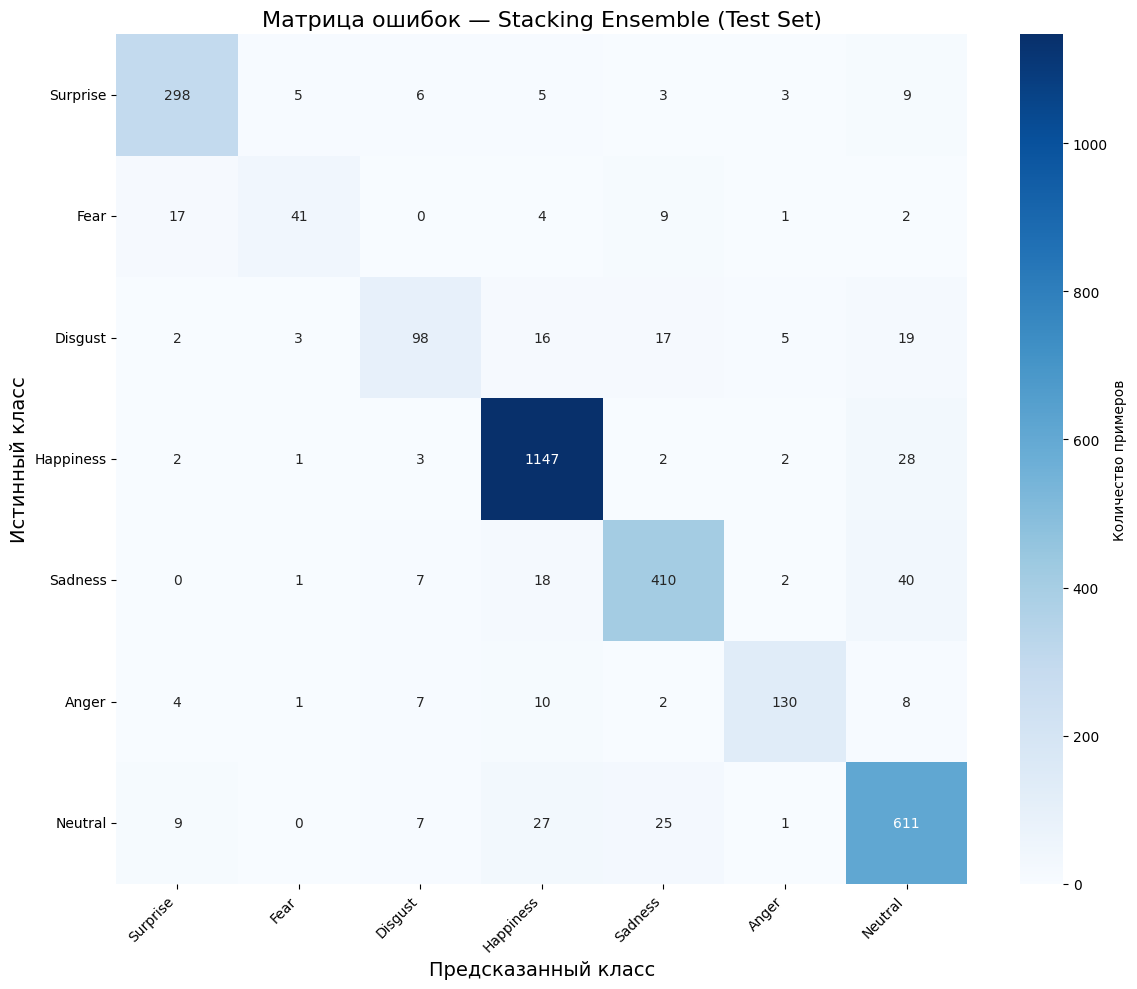

In [17]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import pickle
from pathlib import Path
from PIL import Image
import timm
import warnings
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

RAFDB_ROOT = r"D:\НИР\RAF-DB\DATASET"
SPLITS_PATH = r"D:\НИР\dataset_splits.pkl"

PATH_EFF = r"D:\НИР\Final models\EfficientNet\best_model.pth"
PATH_CONV = r"D:\НИР\Final models\ConvNext\best_model.pth"
PATH_VIT = r"D:\НИР\Final models\ViT\best_model.pth"

BATCH_SIZE = 32

class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes=7, variant='b2', pretrained=True):
        super().__init__()
        if variant == 'b2':
            self.backbone = tv_models.efficientnet_b2(
                weights=tv_models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
            )
            in_features = 1408
        else:
            raise ValueError("Поддерживается только b2")
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        weights = tv_models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = tv_models.convnext_tiny(weights=weights)
        
        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(p=0.35),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class RAFDBDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir) / split
        self.is_train = 'train' in str(self.root_dir).lower()
        self.images = []
        self.labels = []
        self._load_data()

        if self.is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.82, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=12),
                transforms.RandomApply([transforms.ColorJitter(0.12, 0.12, 0.08)], p=0.6),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.25)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)


class FixedSplitDataset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.base_dataset[self.indices[idx]]


def create_dataloaders(batch_size=32):
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)

    full_train_base = RAFDBDataset(RAFDB_ROOT, 'train')
    test_ds = RAFDBDataset(RAFDB_ROOT, 'test')

    train_ds = FixedSplitDataset(full_train_base, splits['train_indices'])
    val_ds   = FixedSplitDataset(full_train_base, splits['val_indices'])

    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
        4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, pin_memory=True)

    return train_loader, val_loader, test_loader, emotion_labels


def load_model(model_class, path, num_classes=7):
    model = model_class(num_classes=num_classes).to(device)
    checkpoint = torch.load(path, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model


model_eff = load_model(EfficientNetEmotion, PATH_EFF)
model_conv = load_model(ConvNeXtEmotion, PATH_CONV)
model_vit = load_model(ViTEmotion, PATH_VIT)

models = [model_eff, model_conv, model_vit]
model_names = ['EfficientNet-B2', 'ConvNeXt-Tiny', 'ViT-Small']


def get_model_probs(model, loader):
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Предсказания {model.__class__.__name__}"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    
    return np.vstack(all_probs), np.concatenate(all_labels)


train_loader, val_loader, test_loader, emotion_labels = create_dataloaders(BATCH_SIZE)

print("\n=== Подготовка данных для Stacking ===")

val_probs_list = []
test_probs_list = []
val_labels = None
test_labels = None

for model in models:
    val_p, val_l = get_model_probs(model, val_loader)
    test_p, test_l = get_model_probs(model, test_loader)
    
    val_probs_list.append(val_p)
    test_probs_list.append(test_p)
    
    if val_labels is None:
        val_labels = val_l
        test_labels = test_l

X_val = np.hstack(val_probs_list)
X_test = np.hstack(test_probs_list)

print(f"Размер признакового пространства: {X_val.shape[1]}")

meta_model = LogisticRegression(
    max_iter=2000,
    C=0.5,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)

meta_model.fit(X_val, val_labels)

val_pred = meta_model.predict(X_val)
test_pred = meta_model.predict(X_test)

print("\n")
print("РЕЗУЛЬТАТЫ STACKING")
print("\n")

print(f"Val Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))

print("\n")
print("Матрица ошибок (Confusion Matrix) для Test")
print("\n")

cm = confusion_matrix(test_labels, test_pred)

print(cm)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Стакинг ансамбль с использованием логистической регрессии с балансировкой весов


Обучение мета-модели (Logistic Regression + balanced weights)
РЕЗУЛЬТАТЫ STACKING (с balanced weights)
Val Accuracy:   0.9902
Test Accuracy:  0.8957
Test Macro F1:  0.8356

Per-class F1-score (Stacking + balanced):
              precision    recall  f1-score   support

    Surprise      0.902     0.894     0.898       329
        Fear      0.730     0.622     0.672        74
     Disgust      0.736     0.681     0.708       160
   Happiness      0.952     0.961     0.956      1185
     Sadness      0.870     0.868     0.869       478
       Anger      0.912     0.827     0.867       162
     Neutral      0.861     0.899     0.879       680

    accuracy                          0.896      3068
   macro avg      0.852     0.822     0.836      3068
weighted avg      0.895     0.896     0.895      3068



МАТРИЦА ОШИБОК (Test Set)
    Surprise     Fear  Disgust Happiness  Sadness    Anger  Neutral
Surprise      294        8        8        5        2        3        9
Fear           15  

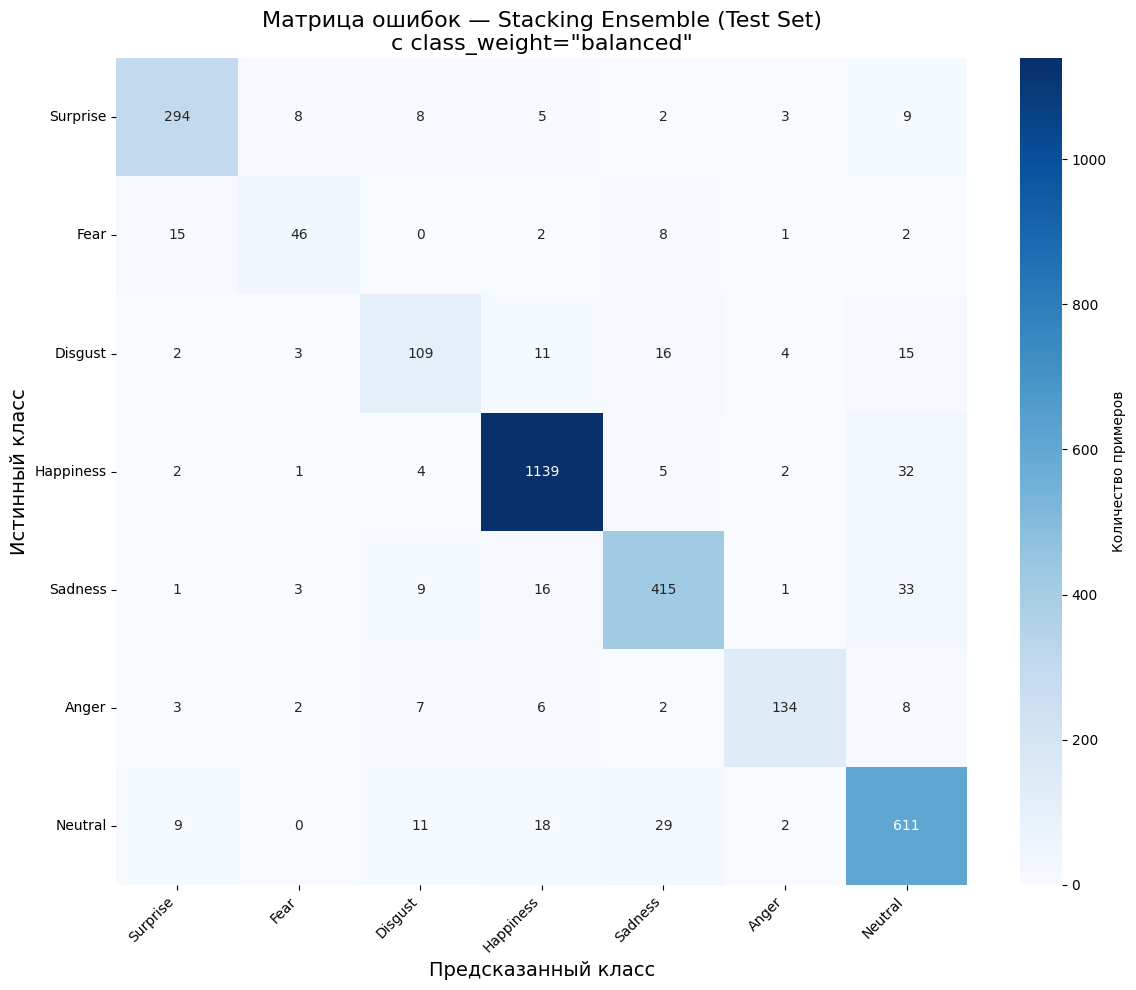

In [ ]:
print("\nОбучение мета-модели (Logistic Regression + balanced weights)")

meta_model = LogisticRegression(
    max_iter=2000,
    C=0.8,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

meta_model.fit(X_val, val_labels)

val_pred = meta_model.predict(X_val)
test_pred = meta_model.predict(X_test)

print("РЕЗУЛЬТАТЫ STACKING (с balanced weights)")

print(f"Val Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking + balanced):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))

print("\n")
print("МАТРИЦА ОШИБОК (Test Set)")


cm = confusion_matrix(test_labels, test_pred)

print("    " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()


Обучение MLP мета-модели 
Epoch 20/150, Train Loss: 0.1742, Val Loss: 0.4557, Val Acc: 0.8957, Val F1: 0.8354
Early stopping at epoch 31


РЕЗУЛЬТАТЫ STACKING с MLP

Test Accuracy: 0.8941
Test Macro F1: 0.8317

Per-class F1-score (MLP Stacking):
              precision    recall  f1-score   support

    Surprise      0.907     0.888     0.897       329
        Fear      0.712     0.635     0.671        74
     Disgust      0.705     0.688     0.696       160
   Happiness      0.956     0.961     0.959      1185
     Sadness      0.861     0.868     0.865       478
       Anger      0.893     0.821     0.855       162
     Neutral      0.865     0.893     0.878       680

    accuracy                          0.894      3068
   macro avg      0.843     0.822     0.832      3068
weighted avg      0.894     0.894     0.894      3068



МАТРИЦА ОШИБОК (Test Set)
    Surprise     Fear  Disgust Happiness  Sadness    Anger  Neutral
Surprise      294        8        8        5        2       

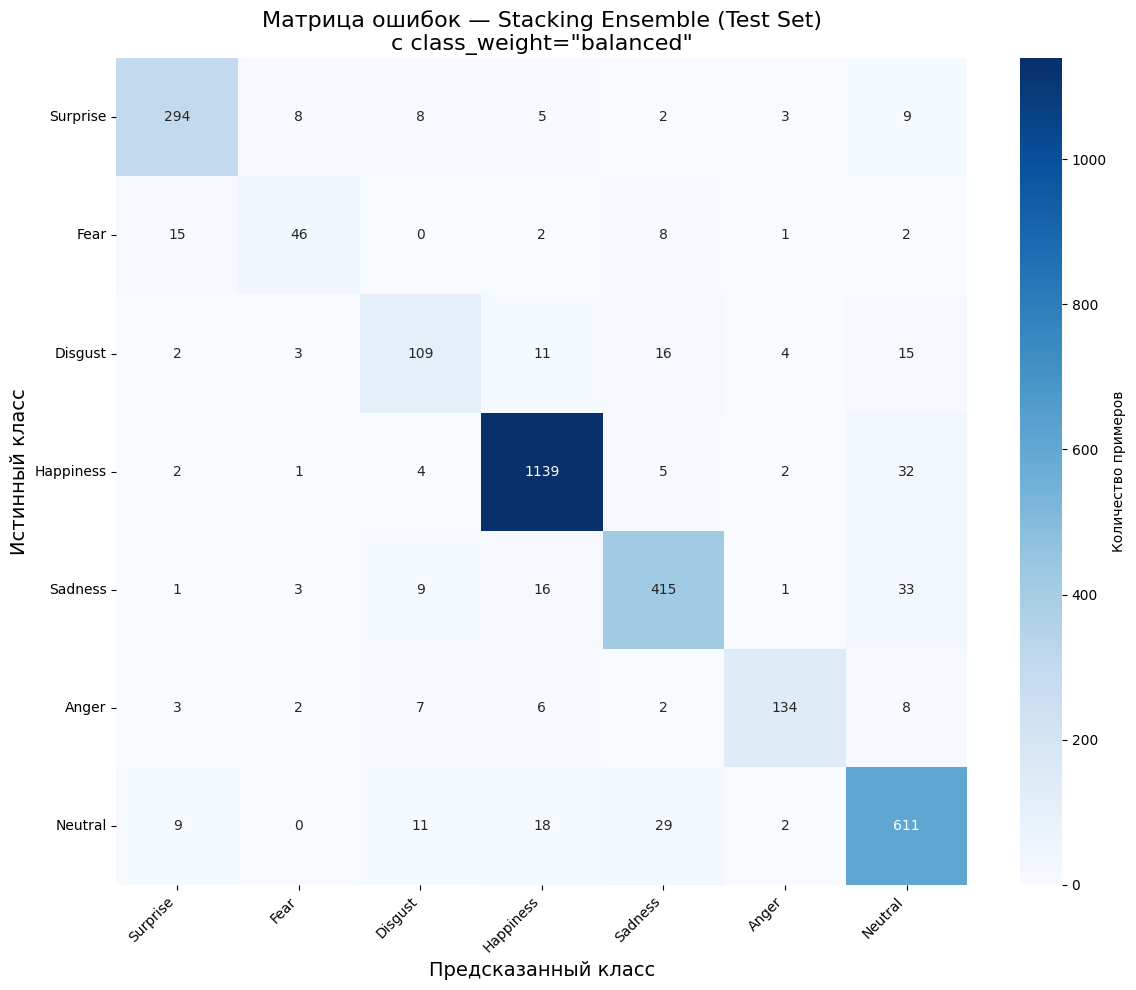

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report

class StackingMLP(nn.Module):
    def __init__(self, input_dim=21, hidden_dims=[128, 64], num_classes=7, dropout=0.3):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

def train_meta_model_mlp(X_train, y_train, X_val, y_val, 
                         hidden_dims=[128, 64], 
                         epochs=100, 
                         batch_size=64,
                         lr=0.001,
                         weight_decay=1e-4):
    
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.LongTensor(y_train)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.LongTensor(y_val)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = StackingMLP(
        input_dim=X_train.shape[1],
        hidden_dims=hidden_dims,
        num_classes=len(np.unique(y_train)),
        dropout=0.3
    ).to(device)
    
    from sklearn.utils.class_weight import compute_class_weight
    class_weights = compute_class_weight('balanced', 
                                        classes=np.unique(y_train), 
                                        y=y_train)
    class_weights = torch.FloatTensor(class_weights).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
    
    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    patience = 20
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())
        
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        scheduler.step(val_loss)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.4f}, "
                  f"Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    model.load_state_dict(best_model_state)
    
    return model


print("\nОбучение MLP мета-модели")

mlp_model = train_meta_model_mlp(
    X_train=X_val,
    y_train=val_labels,
    X_val=X_test,
    y_val=test_labels,
    hidden_dims=[128, 64, 32],
    epochs=150,
    batch_size=64,
    lr=0.0005,
    weight_decay=1e-4
)


mlp_model.eval()
X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    outputs = mlp_model(X_test_t)
    _, mlp_pred = torch.max(outputs, 1)
    mlp_pred = mlp_pred.cpu().numpy()


print("\n")
print("РЕЗУЛЬТАТЫ STACKING с MLP")
print("\n")
print(f"Test Accuracy: {accuracy_score(test_labels, mlp_pred):.4f}")
print(f"Test Macro F1: {f1_score(test_labels, mlp_pred, average='macro'):.4f}")

print("\nPer-class F1-score (MLP Stacking):")
print(classification_report(test_labels, mlp_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))


print("\n")
print("МАТРИЦА ОШИБОК (Test Set)")


cm = confusion_matrix(test_labels, test_pred)

print("    " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Стакинг ансамбль с использованием Слуйчайного Леса с балансировкой весов и Градиентного Бустинга


РЕЗУЛЬТАТЫ STACKING (с balanced weights)
Val Accuracy:   0.9957
Test Accuracy:  0.8905
Test Macro F1:  0.8296

Per-class F1-score (Stacking + balanced):
              precision    recall  f1-score   support

    Surprise      0.903     0.881     0.892       329
        Fear      0.690     0.662     0.676        74
     Disgust      0.722     0.681     0.701       160
   Happiness      0.952     0.960     0.956      1185
     Sadness      0.864     0.866     0.865       478
       Anger      0.870     0.827     0.848       162
     Neutral      0.859     0.879     0.869       680

    accuracy                          0.890      3068
   macro avg      0.837     0.823     0.830      3068
weighted avg      0.890     0.890     0.890      3068


МАТРИЦА ОШИБОК (Test Set)
        Surprise     Fear  Disgust Happiness  Sadness    Anger  Neutral
Surprise      290       10        9        3        3        5        9
Fear           12       49        0        2        8        1        2
Disgus

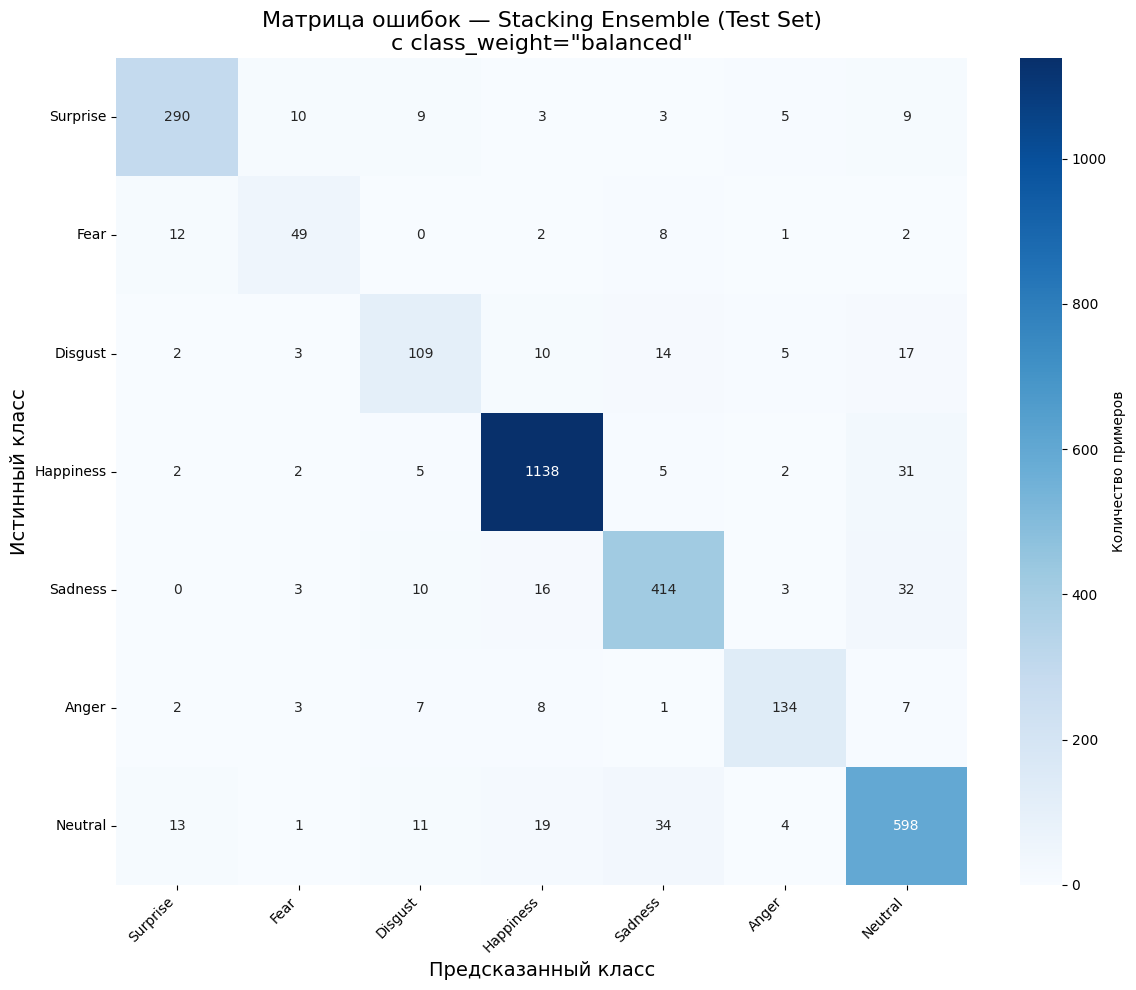

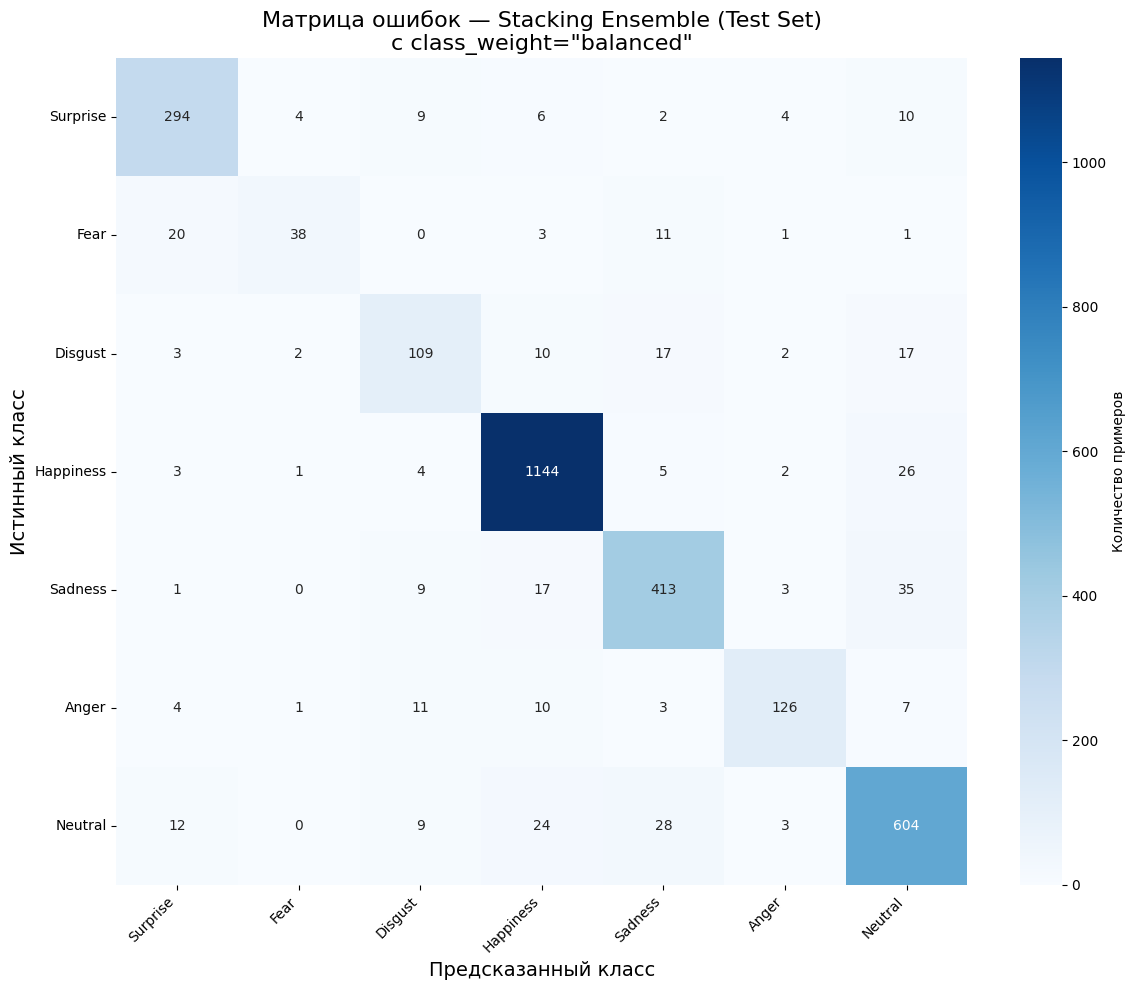

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

meta_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

meta_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

meta_rf.fit(X_val, val_labels)

val_pred = meta_rf.predict(X_val)
test_pred = meta_rf.predict(X_test)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ STACKING (с balanced weights)")
print("="*70)

print(f"Val Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking + balanced):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))

print("\n" + "="*70)
print("МАТРИЦА ОШИБОК (Test Set)")
print("="*70)

cm = confusion_matrix(test_labels, test_pred)


print("         " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

meta_gb.fit(X_val, val_labels)

val_pred = meta_gb.predict(X_val)
test_pred = meta_gb.predict(X_test)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ STACKING (с balanced weights)")
print("="*70)

print(f"Val Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking + balanced):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))

print("\n" + "="*70)
print("МАТРИЦА ОШИБОК (Test Set)")
print("="*70)

cm = confusion_matrix(test_labels, test_pred)


print("         " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# EfficientNet-B2 + ConvNeXt-Tiny

Используется устройство: cuda

Подготовка данных для Stacking


Предсказания ConvNeXtEmotion: 100%|██████████| 96/96 [00:18<00:00,  5.24it/s]


Размер признакового пространства: 14


РЕЗУЛЬТАТЫ STACKING (с balanced weights)


Val Accuracy:   0.9772
Test Accuracy:  0.8765
Test Macro F1:  0.8063

Per-class F1-score (Stacking + balanced):
              precision    recall  f1-score   support

    Surprise      0.878     0.872     0.875       329
        Fear      0.697     0.622     0.657        74
     Disgust      0.706     0.600     0.649       160
   Happiness      0.943     0.953     0.948      1185
     Sadness      0.853     0.851     0.852       478
       Anger      0.834     0.778     0.805       162
     Neutral      0.838     0.879     0.858       680

    accuracy                          0.876      3068
   macro avg      0.821     0.794     0.806      3068
weighted avg      0.875     0.876     0.875      3068



МАТРИЦА ОШИБОК (Test Set)


   Surprise     Fear  Disgust Happiness  Sadness    Anger  Neutral
Surprise      287        9        6        5        5        6       11
Fear           12       46        0     

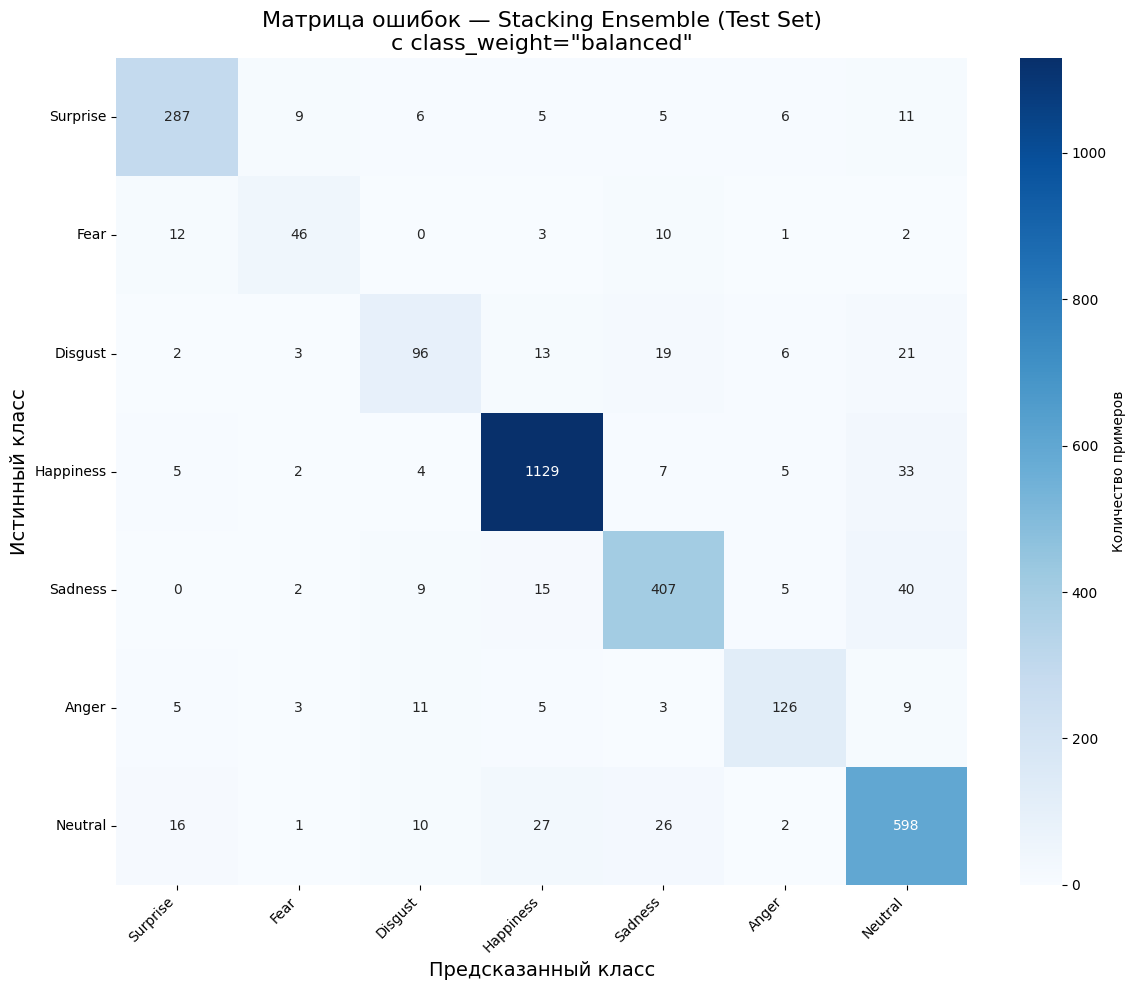

In [14]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import pickle
from pathlib import Path
from PIL import Image
import timm
import warnings
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

RAFDB_ROOT = r"D:\НИР\RAF-DB\DATASET"
SPLITS_PATH = r"D:\НИР\dataset_splits.pkl"

PATH_EFF = r"D:\НИР\Final models\EfficientNet\best_model.pth"
PATH_CONV = r"D:\НИР\Final models\ConvNext\best_model.pth"

BATCH_SIZE = 32


class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes=7, variant='b2', pretrained=True):
        super().__init__()
        if variant == 'b2':
            self.backbone = tv_models.efficientnet_b2(
                weights=tv_models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
            )
            in_features = 1408
        else:
            raise ValueError("Поддерживается только b2")
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        weights = tv_models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = tv_models.convnext_tiny(weights=weights)
        
        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(p=0.35),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class RAFDBDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir) / split
        self.is_train = 'train' in str(self.root_dir).lower()
        self.images = []
        self.labels = []
        self._load_data()

        if self.is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.82, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=12),
                transforms.RandomApply([transforms.ColorJitter(0.12, 0.12, 0.08)], p=0.6),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.25)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)


class FixedSplitDataset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.base_dataset[self.indices[idx]]


def create_dataloaders(batch_size=32):
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)

    full_train_base = RAFDBDataset(RAFDB_ROOT, 'train')
    test_ds = RAFDBDataset(RAFDB_ROOT, 'test')

    train_ds = FixedSplitDataset(full_train_base, splits['train_indices'])
    val_ds   = FixedSplitDataset(full_train_base, splits['val_indices'])

    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
        4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, pin_memory=True)

    return train_loader, val_loader, test_loader, emotion_labels


def load_model(model_class, path, num_classes=7):
    model = model_class(num_classes=num_classes).to(device)
    checkpoint = torch.load(path, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model


model_eff = load_model(EfficientNetEmotion, PATH_EFF)
model_conv = load_model(ConvNeXtEmotion, PATH_CONV)

models = [model_eff, model_conv]
model_names = ['EfficientNet-B2', 'ConvNeXt-Tiny']


def get_model_probs(model, loader):
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Предсказания {model.__class__.__name__}"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    
    return np.vstack(all_probs), np.concatenate(all_labels)


train_loader, val_loader, test_loader, emotion_labels = create_dataloaders(BATCH_SIZE)

print("\nПодготовка данных для Stacking")

val_probs_list = []
test_probs_list = []
val_labels = None
test_labels = None

for model in models:
    val_p, val_l = get_model_probs(model, val_loader)
    test_p, test_l = get_model_probs(model, test_loader)
    
    val_probs_list.append(val_p)
    test_probs_list.append(test_p)
    
    if val_labels is None:
        val_labels = val_l
        test_labels = test_l

X_val = np.hstack(val_probs_list)
X_test = np.hstack(test_probs_list)

print(f"Размер признакового пространства: {X_val.shape[1]}")

meta_model = LogisticRegression(
    max_iter=2000,
    C=0.8,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

meta_model.fit(X_val, val_labels)

val_pred = meta_model.predict(X_val)
test_pred = meta_model.predict(X_test)

print("\n")
print("РЕЗУЛЬТАТЫ STACKING (с balanced weights)")
print("\n")

print(f"Val Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking + balanced):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))


print("\n")
print("МАТРИЦА ОШИБОК (Test Set)")
print("\n")

cm = confusion_matrix(test_labels, test_pred)

print("   " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# EfficientNet-B2 + ViT-Small

Используется устройство: cuda

Подготовка данных для Stacking


Предсказания ViTEmotion: 100%|██████████| 96/96 [00:16<00:00,  5.93it/s]


Размер признакового пространства: 14


РЕЗУЛЬТАТЫ STACKING (с balanced weights)


Val Accuracy:   0.9739
Test Accuracy:  0.8843
Test Macro F1:  0.8174

Per-class F1-score (Stacking + balanced):
              precision    recall  f1-score   support

    Surprise      0.896     0.888     0.892       329
        Fear      0.733     0.595     0.657        74
     Disgust      0.634     0.694     0.663       160
   Happiness      0.943     0.964     0.953      1185
     Sadness      0.851     0.862     0.857       478
       Anger      0.900     0.778     0.834       162
     Neutral      0.872     0.862     0.867       680

    accuracy                          0.884      3068
   macro avg      0.833     0.806     0.817      3068
weighted avg      0.884     0.884     0.884      3068



МАТРИЦА ОШИБОК (Test Set)


   Surprise     Fear  Disgust Happiness  Sadness    Anger  Neutral
Surprise      292        8       12        2        3        3        9
Fear           14       44        0     

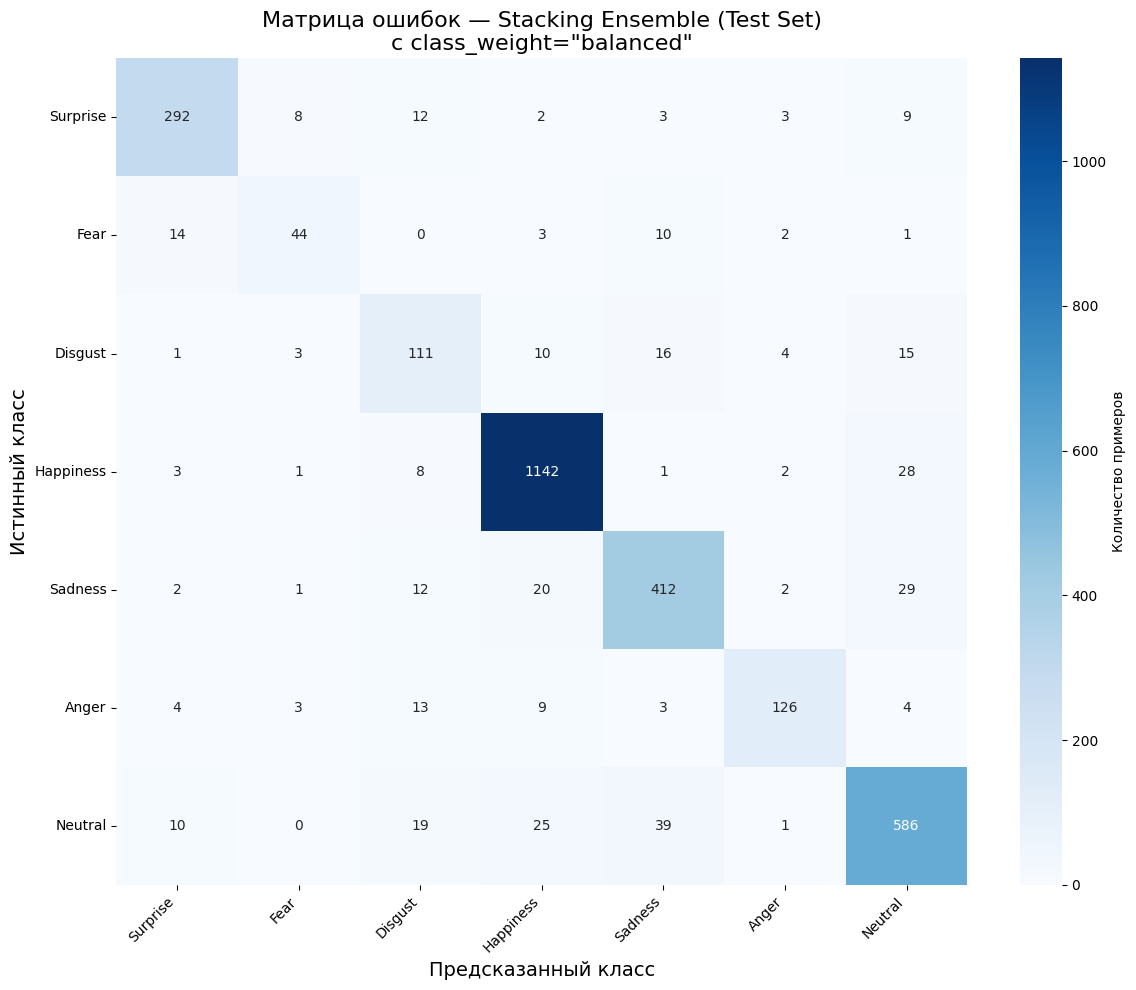

In [11]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import pickle
from pathlib import Path
from PIL import Image
import timm
import warnings
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

RAFDB_ROOT = r"D:\НИР\RAF-DB\DATASET"
SPLITS_PATH = r"D:\НИР\dataset_splits.pkl"

# Пути к моделям
PATH_EFF = r"D:\НИР\Final models\EfficientNet\best_model.pth"
PATH_VIT = r"D:\НИР\Final models\ViT\best_model.pth"

BATCH_SIZE = 32


class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes=7, variant='b2', pretrained=True):
        super().__init__()
        if variant == 'b2':
            self.backbone = tv_models.efficientnet_b2(
                weights=tv_models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
            )
            in_features = 1408
        else:
            raise ValueError("Поддерживается только b2")
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class RAFDBDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir) / split
        self.is_train = 'train' in str(self.root_dir).lower()
        self.images = []
        self.labels = []
        self._load_data()

        if self.is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.82, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=12),
                transforms.RandomApply([transforms.ColorJitter(0.12, 0.12, 0.08)], p=0.6),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.25)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)


class FixedSplitDataset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.base_dataset[self.indices[idx]]


def create_dataloaders(batch_size=32):
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)

    full_train_base = RAFDBDataset(RAFDB_ROOT, 'train')
    test_ds = RAFDBDataset(RAFDB_ROOT, 'test')

    train_ds = FixedSplitDataset(full_train_base, splits['train_indices'])
    val_ds   = FixedSplitDataset(full_train_base, splits['val_indices'])

    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
        4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, pin_memory=True)

    return train_loader, val_loader, test_loader, emotion_labels


def load_model(model_class, path, num_classes=7):
    model = model_class(num_classes=num_classes).to(device)
    checkpoint = torch.load(path, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model


model_eff = load_model(EfficientNetEmotion, PATH_EFF)
model_vit = load_model(ViTEmotion, PATH_VIT)

models = [model_eff, model_vit]
model_names = ['EfficientNet-B2', 'ViT-Small']


def get_model_probs(model, loader):
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Предсказания {model.__class__.__name__}"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    
    return np.vstack(all_probs), np.concatenate(all_labels)


train_loader, val_loader, test_loader, emotion_labels = create_dataloaders(BATCH_SIZE)

print("\nПодготовка данных для Stacking")

val_probs_list = []
test_probs_list = []
val_labels = None
test_labels = None

for model in models:
    val_p, val_l = get_model_probs(model, val_loader)
    test_p, test_l = get_model_probs(model, test_loader)
    
    val_probs_list.append(val_p)
    test_probs_list.append(test_p)
    
    if val_labels is None:
        val_labels = val_l
        test_labels = test_l

X_val = np.hstack(val_probs_list)
X_test = np.hstack(test_probs_list)

print(f"Размер признакового пространства: {X_val.shape[1]}")


meta_model = LogisticRegression(
    max_iter=2000,
    C=0.8,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

meta_model.fit(X_val, val_labels)

val_pred = meta_model.predict(X_val)
test_pred = meta_model.predict(X_test)

print("\n")
print("РЕЗУЛЬТАТЫ STACKING (с balanced weights)")
print("\n")

print(f"Val Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking + balanced):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))


print("\n")
print("МАТРИЦА ОШИБОК (Test Set)")
print("\n")

cm = confusion_matrix(test_labels, test_pred)

print("   " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# ConvNeXt-Tiny + ViT-Small

Используется устройство: cuda

Подготовка данных для Stacking


Предсказания ViTEmotion: 100%|██████████| 96/96 [00:16<00:00,  5.88it/s]


Размер признакового пространства: 14


РЕЗУЛЬТАТЫ STACKING (с balanced weights)


Val Accuracy:   0.9842
Test Accuracy:  0.8856
Test Macro F1:  0.8178

Per-class F1-score (Stacking + balanced):
              precision    recall  f1-score   support

    Surprise      0.876     0.878     0.877       329
        Fear      0.697     0.622     0.657        74
     Disgust      0.675     0.688     0.681       160
   Happiness      0.945     0.963     0.954      1185
     Sadness      0.886     0.845     0.865       478
       Anger      0.858     0.784     0.819       162
     Neutral      0.861     0.882     0.871       680

    accuracy                          0.886      3068
   macro avg      0.828     0.809     0.818      3068
weighted avg      0.885     0.886     0.885      3068



МАТРИЦА ОШИБОК (Test Set)


   Surprise     Fear  Disgust Happiness  Sadness    Anger  Neutral
Surprise      289        9        9        4        4        6        8
Fear           16       46        0     

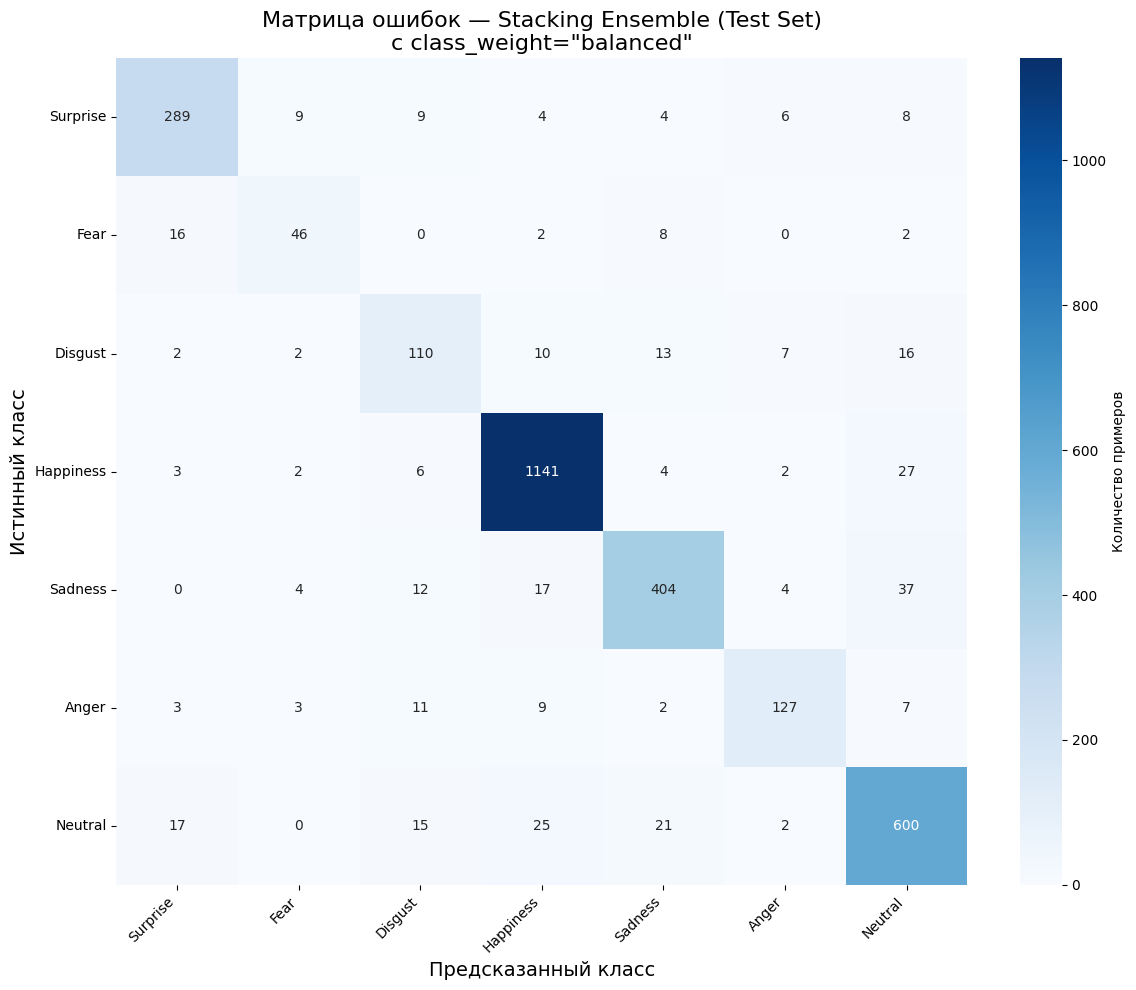

In [16]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import pickle
from pathlib import Path
from PIL import Image
import timm
import warnings
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

RAFDB_ROOT = r"D:\НИР\RAF-DB\DATASET"
SPLITS_PATH = r"D:\НИР\dataset_splits.pkl"

PATH_CONV = r"D:\НИР\Final models\ConvNext\best_model.pth"
PATH_VIT = r"D:\НИР\Final models\ViT\best_model.pth"

BATCH_SIZE = 32


class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        weights = tv_models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = tv_models.convnext_tiny(weights=weights)
        
        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(p=0.35),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )
        self.to(device)

    def forward(self, x):
        return self.backbone(x.to(device))


class RAFDBDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir) / split
        self.is_train = 'train' in str(self.root_dir).lower()
        self.images = []
        self.labels = []
        self._load_data()

        if self.is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.82, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=12),
                transforms.RandomApply([transforms.ColorJitter(0.12, 0.12, 0.08)], p=0.6),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.25)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)


class FixedSplitDataset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.base_dataset[self.indices[idx]]


def create_dataloaders(batch_size=32):
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)

    full_train_base = RAFDBDataset(RAFDB_ROOT, 'train')
    test_ds = RAFDBDataset(RAFDB_ROOT, 'test')

    train_ds = FixedSplitDataset(full_train_base, splits['train_indices'])
    val_ds   = FixedSplitDataset(full_train_base, splits['val_indices'])

    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
        4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, pin_memory=True)

    return train_loader, val_loader, test_loader, emotion_labels


def load_model(model_class, path, num_classes=7):
    model = model_class(num_classes=num_classes).to(device)
    checkpoint = torch.load(path, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model


model_conv = load_model(ConvNeXtEmotion, PATH_CONV)
model_vit = load_model(ViTEmotion, PATH_VIT)

models = [model_conv, model_vit]
model_names = ['ConvNeXt-Tiny', 'ViT-Small']


def get_model_probs(model, loader):
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Предсказания {model.__class__.__name__}"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    
    return np.vstack(all_probs), np.concatenate(all_labels)


train_loader, val_loader, test_loader, emotion_labels = create_dataloaders(BATCH_SIZE)

print("\nПодготовка данных для Stacking")

val_probs_list = []
test_probs_list = []
val_labels = None
test_labels = None

for model in models:
    val_p, val_l = get_model_probs(model, val_loader)
    test_p, test_l = get_model_probs(model, test_loader)
    
    val_probs_list.append(val_p)
    test_probs_list.append(test_p)
    
    if val_labels is None:
        val_labels = val_l
        test_labels = test_l

X_val = np.hstack(val_probs_list)
X_test = np.hstack(test_probs_list)

print(f"Размер признакового пространства: {X_val.shape[1]}")


meta_model = LogisticRegression(
    max_iter=2000,
    C=0.8,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

meta_model.fit(X_val, val_labels)

val_pred = meta_model.predict(X_val)
test_pred = meta_model.predict(X_test)

print("\n")
print("РЕЗУЛЬТАТЫ STACKING (с balanced weights)")
print("\n")

print(f"Val Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking + balanced):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))


print("\n")
print("МАТРИЦА ОШИБОК (Test Set)")
print("\n")

cm = confusion_matrix(test_labels, test_pred)

print("   " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()